# 🚀 LLM Benchmark Analysis

This notebook analyzes the performance of different Large Language Models (LLMs) running on Ollama.

---

## 🧒 Explain Like I'm 5

Imagine you have three different robots 🤖 that can answer questions. We want to know:
- **Which robot thinks the fastest?** (Time to First Token)
- **Which robot talks the fastest?** (Tokens per Second)
- **Which robot finishes answering first?** (Total Time)
- **Which robot needs the biggest lunch box?** (Memory Usage)

This notebook shows us all of that with pretty pictures! 📊

## 📦 Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from io import StringIO

# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries loaded!")

✅ Libraries loaded!


### Load CSV Data

Paste your benchmark CSV output in the cell below, or load from a file.

The CSV should have these columns:
- `model` - Model name (e.g., qwen2.5:3b)
- `prompt_i` - Prompt index (1-4)
- `run_i` - Run iteration
- `ttft_s` - Time to First Token (seconds)
- `wall_s` - Total wall clock time (seconds)
- `gen_s` - Generation time (seconds)
- `eval_count` - Number of tokens generated
- `tps_eval` - Tokens per second (based on eval duration)
- `tps_wall` - Tokens per second (wall clock)
- `mem_peak_mib` - Peak memory usage (MiB)

In [2]:
# Option 1: Paste your CSV data here
csv_data = """
model,prompt_i,run_i,ttft_s,wall_s,gen_s,eval_count,tps_eval,tps_wall,mem_peak_mib
qwen2.5:3b,1,1,10.7000,44.3050,33.6050,220,6.5467,6.5466,2325.0
qwen2.5:3b,1,2,0.7189,34.2129,33.4940,220,6.5686,6.5683,2337.0
qwen2.5:3b,2,1,1.6532,35.4030,33.7498,220,6.5183,6.5186,2346.0
qwen2.5:3b,2,2,0.6567,34.5836,33.9269,220,6.4845,6.4845,2353.0
qwen2.5:3b,3,1,2.2996,4.0778,1.7781,14,7.8731,7.8734,2353.0
qwen2.5:3b,3,2,0.5748,2.7996,2.2248,15,6.7459,6.7423,2353.0
qwen2.5:3b,4,1,2.1304,35.6792,33.5488,220,6.5537,6.5576,2366.0
qwen2.5:3b,4,2,0.5421,33.5664,33.0243,220,6.6625,6.6618,2375.0
qwen3.5:4b,1,1,67.2334,67.2334,0.0000,220,4.4094,220000000000.0000,4749.0
qwen3.5:4b,1,2,51.5816,51.5816,0.0000,220,4.3864,220000000000.0000,4905.0
qwen3.5:4b,2,1,32.6038,55.4144,22.8105,220,4.2589,9.6447,5006.0
qwen3.5:4b,2,2,44.0624,52.5261,8.4636,220,4.3090,25.9935,5006.0
qwen3.5:4b,3,1,54.5493,54.5493,0.0000,220,4.3967,220000000000.0000,4496.0
qwen3.5:4b,3,2,52.3479,52.3479,0.0000,220,4.3420,220000000000.0000,4641.0
qwen3.5:4b,4,1,53.6381,53.6381,0.0000,220,4.4119,220000000000.0000,4763.0
qwen3.5:4b,4,2,52.6397,52.6397,0.0000,220,4.2963,220000000000.0000,4921.0
phi3:mini,1,1,12.3040,51.8328,39.5288,220,5.5659,5.5656,4921.0
phi3:mini,1,2,0.3612,39.6771,39.3158,220,5.5960,5.5957,3991.0
phi3:mini,2,1,2.0414,12.6776,10.6362,65,6.1114,6.1112,4081.0
phi3:mini,2,2,0.3966,39.9428,39.5462,220,5.5592,5.5631,4114.0
phi3:mini,3,1,3.1020,8.0910,4.9890,29,5.8116,5.8128,4114.0
phi3:mini,3,2,0.2896,3.5692,3.2795,22,6.6267,6.7083,4114.0
phi3:mini,4,1,2.1591,41.2445,39.0855,220,5.6285,5.6287,4218.0
phi3:mini,4,2,0.3753,39.0202,38.6449,220,5.6928,5.6929,4312.0
mistral:7b,1,1,21.2894,94.3031,73.0136,220,3.0129,3.0131,4948.0
mistral:7b,1,2,0.5930,71.1146,70.5216,220,3.1186,3.1196,4980.0
mistral:7b,2,1,2.5230,75.3118,72.7888,220,3.0222,3.0224,5009.0
mistral:7b,2,2,0.4545,72.0780,71.6235,220,3.0700,3.0716,5040.0
mistral:7b,3,1,5.4146,12.7438,7.3292,22,3.0021,3.0017,5040.0
mistral:7b,3,2,0.4447,8.3364,7.8917,25,3.1569,3.1679,5071.0
mistral:7b,4,1,3.4169,75.9293,72.5124,220,3.0338,3.0340,5077.0
mistral:7b,4,2,0.5104,72.8671,72.3567,220,3.0406,3.0405,5108.0
llama3.2:latest,1,1,13.3364,48.6122,35.2758,220,6.2363,6.2366,5108.0
llama3.2:latest,1,2,0.6811,36.8139,36.1328,220,6.0905,6.0886,2594.0
llama3.2:latest,2,1,1.7741,31.7384,29.9643,190,6.3409,6.3409,2622.0
llama3.2:latest,2,2,0.6688,35.3529,34.6842,214,6.1702,6.1700,2648.0
llama3.2:latest,3,1,2.4213,6.3189,3.8976,27,6.8912,6.9273,2648.0
llama3.2:latest,3,2,0.6691,3.5342,2.8651,17,5.9311,5.9334,2648.0
llama3.2:latest,4,1,1.8076,37.9064,36.0988,220,6.0941,6.0944,2677.0
llama3.2:latest,4,2,0.8774,36.7981,35.9207,220,6.1245,6.1246,2706.0
""".strip()

# Option 2: Load from file (uncomment if you have a CSV file)
# df = pd.read_csv('benchmark_results.csv')

# Parse the CSV
df = pd.read_csv(StringIO(csv_data))

print(f"📊 Loaded {len(df)} benchmark runs")
print(f"🤖 Models tested: {df['model'].nunique()}")
print(f"📝 Prompts used: {df['prompt_i'].nunique()}")
df.head()

📊 Loaded 40 benchmark runs
🤖 Models tested: 5
📝 Prompts used: 4


,model,prompt_i,run_i,ttft_s,wall_s,gen_s,eval_count,tps_eval,tps_wall,mem_peak_mib
0,qwen2.5:3b,1,1,10.7000,44.3050,33.6050,220,6.5467,6.5466,2325.0
1,qwen2.5:3b,1,2,0.7189,34.2129,33.4940,220,6.5686,6.5683,2337.0
2,qwen2.5:3b,2,1,1.6532,35.4030,33.7498,220,6.5183,6.5186,2346.0
3,qwen2.5:3b,2,2,0.6567,34.5836,33.9269,220,6.4845,6.4845,2353.0
4,qwen2.5:3b,3,1,2.2996,4.0778,1.7781,14,7.8731,7.8734,2353.0


---

# 📊 Technical Analysis

## Key Metrics Explained

| Metric | Description | Why It Matters |
|--------|-------------|----------------|
| **TTFT** (Time to First Token) | Latency before generation starts | User-perceived responsiveness |
| **TPS** (Tokens per Second) | Generation throughput | Raw model speed |
| **Wall Time** | Total end-to-end duration | Real-world completion time |
| **Memory Peak** | Maximum RAM used | Hardware requirements |

## 📈 Summary Statistics by Model

In [3]:
# Calculate summary statistics
summary = df.groupby('model').agg({
    'ttft_s': ['median', 'std', 'min', 'max'],
    'tps_eval': ['median', 'std', 'min', 'max'],
    'wall_s': ['median', 'std', 'min', 'max'],
    'mem_peak_mib': ['max', 'mean'],
    'eval_count': ['mean', 'sum']
}).round(3)

# Flatten column names
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

print("📊 Summary Statistics by Model\n")
summary

📊 Summary Statistics by Model



,model,ttft_s_median,ttft_s_std,ttft_s_min,ttft_s_max,tps_eval_median,tps_eval_std,tps_eval_min,tps_eval_max,wall_s_median,wall_s_std,wall_s_min,wall_s_max,mem_peak_mib_max,mem_peak_mib_mean,eval_count_mean,eval_count_sum
0,llama3.2:latest,1.326,4.317,0.669,13.336,6.147,0.291,5.931,6.891,36.076,16.006,3.534,48.612,5108.0,2956.375,166.000,1328
1,mistral:7b,1.558,7.087,0.445,21.289,3.037,0.055,3.002,3.157,72.473,31.626,8.336,94.303,5108.0,5034.125,170.875,1367
2,phi3:mini,1.219,4.055,0.290,12.304,5.661,0.372,5.559,6.627,39.349,18.337,3.569,51.833,4921.0,4233.125,152.000,1216
3,qwen2.5:3b,1.186,3.426,0.542,10.700,6.561,0.464,6.484,7.873,34.398,15.583,2.800,44.305,2375.0,2351.000,168.625,1349
4,qwen3.5:4b,52.494,9.816,32.604,67.233,4.364,0.058,4.259,4.412,53.139,5.103,51.582,67.233,5006.0,4810.875,220.000,1760


---

## 🧒 ELI5: What do these numbers mean?

- **ttft_s_median**: How long each robot takes to start talking (lower = better!)
- **tps_eval_median**: How many words per second each robot can say (higher = better!)
- **wall_s_median**: How long until the robot is done talking (lower = better!)
- **mem_peak_mib_max**: How big a lunch box the robot needs (lower = runs on smaller computers!)

---

# 📊 Visualizations

## 1. Tokens Per Second Comparison

This is the **raw speed** of each model - how fast it can generate text.

/var/folders/f5/r61jwbt97tqgnkp08qgrx9700000gp/T/ipykernel_53919/2112886926.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y='tps_eval', ax=ax1, palette='husl')


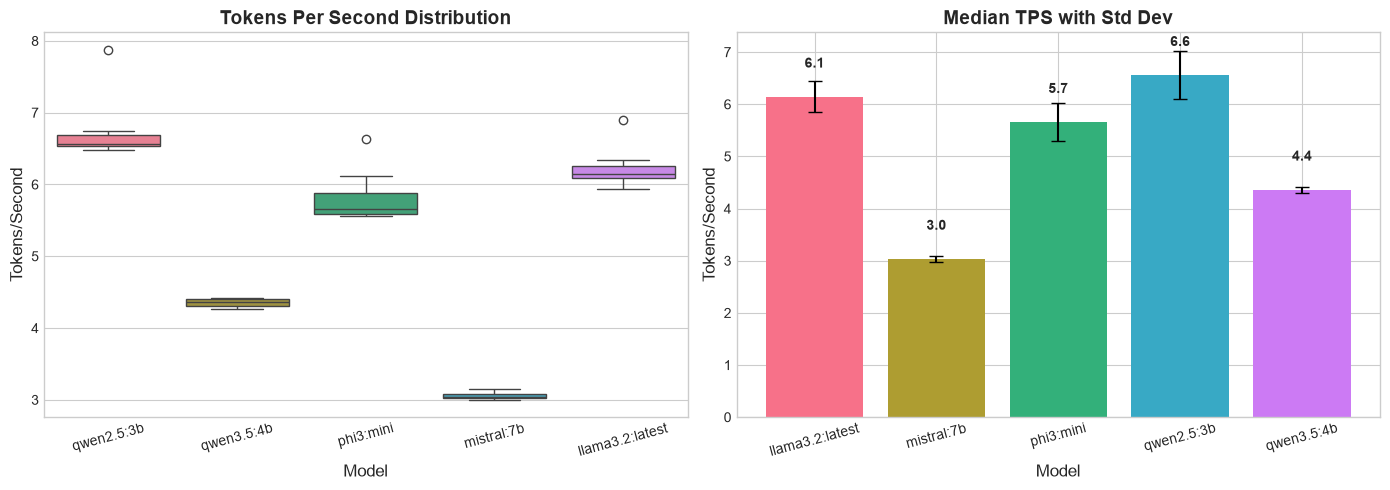

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax1 = axes[0]
sns.boxplot(data=df, x='model', y='tps_eval', ax=ax1, palette='husl')
ax1.set_title('Tokens Per Second Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Tokens/Second', fontsize=12)
ax1.tick_params(axis='x', rotation=15)

# Bar chart with error bars
ax2 = axes[1]
model_tps = df.groupby('model')['tps_eval'].agg(['median', 'std']).reset_index()
bars = ax2.bar(model_tps['model'], model_tps['median'], 
               yerr=model_tps['std'], capsize=5, 
               color=sns.color_palette('husl', len(model_tps)))
ax2.set_title('Median TPS with Std Dev', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Tokens/Second', fontsize=12)
ax2.tick_params(axis='x', rotation=15)

# Add value labels on bars
for bar, val in zip(bars, model_tps['median']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 🧒 ELI5: The Speed Race!

Imagine each robot is saying words as fast as it can. The taller the bar, the more words it can say every second!

🏆 **The winner is the one with the tallest bar!**

---

## 2. Time to First Token (TTFT) - Latency Analysis

**Critical for UX** - How quickly does the user see the first response?

/var/folders/f5/r61jwbt97tqgnkp08qgrx9700000gp/T/ipykernel_53919/49072177.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='model', y='ttft_s', ax=ax1, palette='husl', inner='box')
/var/folders/f5/r61jwbt97tqgnkp08qgrx9700000gp/T/ipykernel_53919/49072177.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='model', y='ttft_s', ax=ax2, palette='husl',


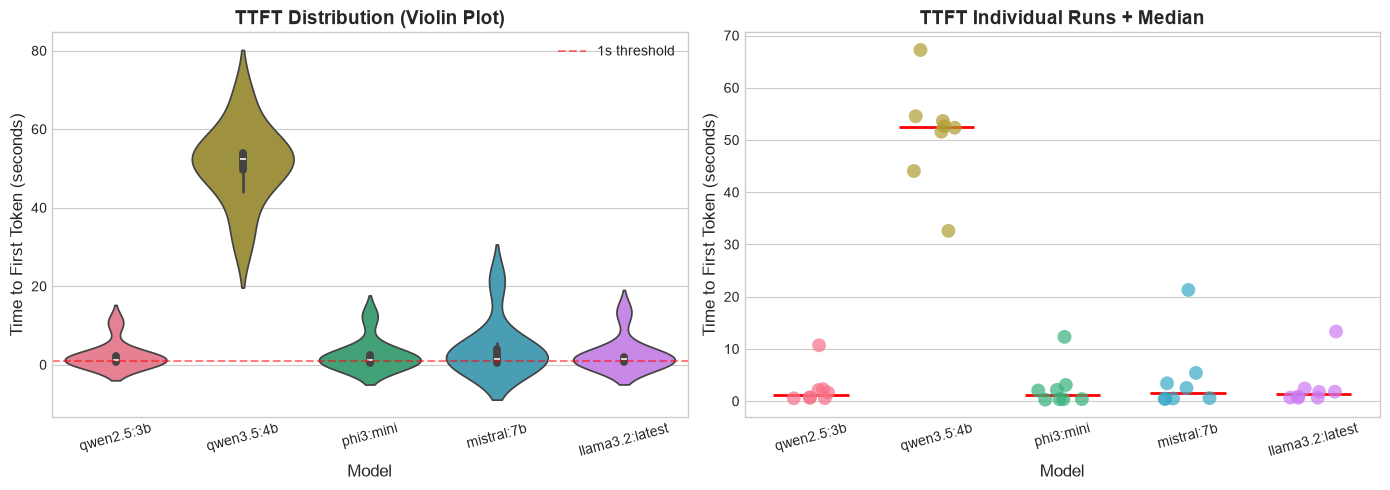

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot shows distribution shape
ax1 = axes[0]
sns.violinplot(data=df, x='model', y='ttft_s', ax=ax1, palette='husl', inner='box')
ax1.set_title('TTFT Distribution (Violin Plot)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Time to First Token (seconds)', fontsize=12)
ax1.tick_params(axis='x', rotation=15)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='1s threshold')
ax1.legend()

# Strip plot with jitter shows individual points
ax2 = axes[1]
sns.stripplot(data=df, x='model', y='ttft_s', ax=ax2, palette='husl', 
              size=10, alpha=0.7, jitter=0.2)
median_ttft = df.groupby('model')['ttft_s'].median()
for i, model in enumerate(df['model'].unique()):
    ax2.hlines(median_ttft[model], i-0.3, i+0.3, colors='red', linewidth=2, label='median' if i==0 else '')
ax2.set_title('TTFT Individual Runs + Median', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Time to First Token (seconds)', fontsize=12)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 🧒 ELI5: The Thinking Time!

When you ask a robot a question, it needs to think before it answers. 

**TTFT** is how long you have to wait before the robot starts talking. ⏱️

The shorter the wait (lower bar), the better! Nobody likes waiting! 😤

---

## 3. Total Wall Time Analysis

End-to-end time from request to completion.

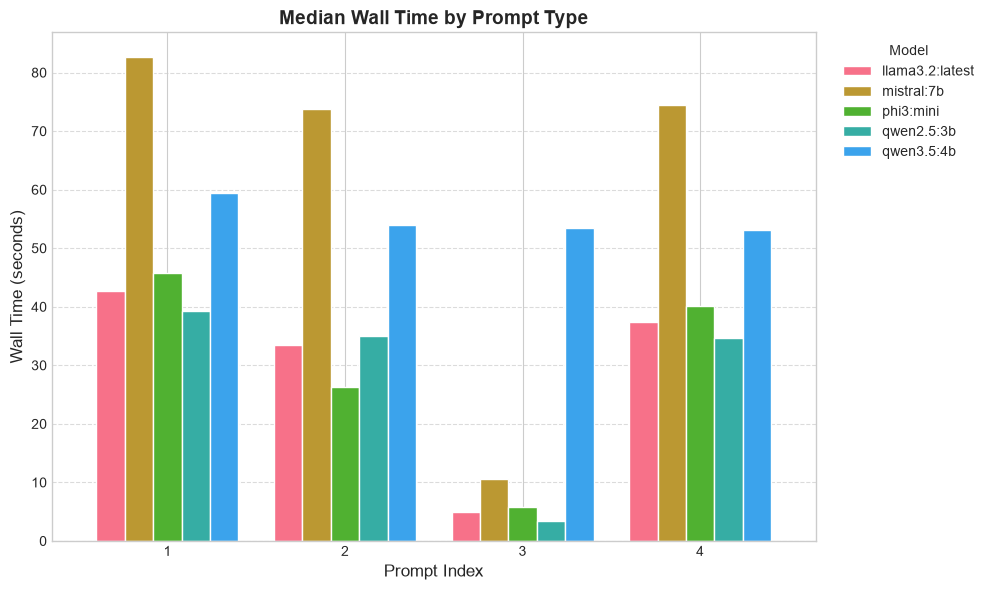

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bar chart by prompt
pivot_wall = df.pivot_table(values='wall_s', index='prompt_i', columns='model', aggfunc='median')
pivot_wall.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1)

ax.set_title('Median Wall Time by Prompt Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Prompt Index', fontsize=12)
ax.set_ylabel('Wall Time (seconds)', fontsize=12)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

# Add gridlines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 🧒 ELI5: The Finish Line! 🏁

This shows how long it takes each robot to finish answering different questions.

Some questions are easy (short bars), some are hard (tall bars)!

The robot that finishes first (shortest bars) wins the race! 🥇

---

## 4. Memory Usage Analysis

**Critical for deployment planning** - RAM requirements per model.

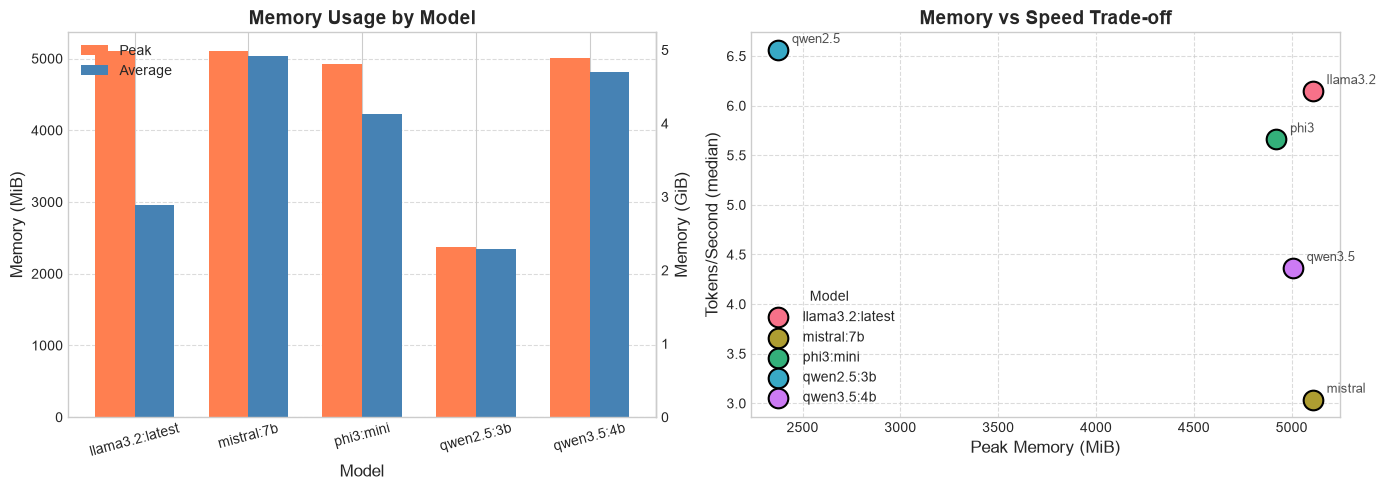

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of max memory
ax1 = axes[0]
mem_stats = df.groupby('model')['mem_peak_mib'].agg(['max', 'mean']).reset_index()
x = np.arange(len(mem_stats))
width = 0.35

bars1 = ax1.bar(x - width/2, mem_stats['max'], width, label='Peak', color='coral')
bars2 = ax1.bar(x + width/2, mem_stats['mean'], width, label='Average', color='steelblue')

ax1.set_title('Memory Usage by Model', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Memory (MiB)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(mem_stats['model'], rotation=15)
ax1.legend()
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add GB scale on right axis
ax1_gb = ax1.secondary_yaxis('right', functions=(lambda x: x/1024, lambda x: x*1024))
ax1_gb.set_ylabel('Memory (GiB)', fontsize=12)

# Memory vs Speed scatter
ax2 = axes[1]
model_summary = df.groupby('model').agg({
    'mem_peak_mib': 'max',
    'tps_eval': 'median'
}).reset_index()

colors = sns.color_palette('husl', len(model_summary))
for i, row in model_summary.iterrows():
    ax2.scatter(row['mem_peak_mib'], row['tps_eval'], s=200, c=[colors[i]], 
                label=row['model'], edgecolors='black', linewidth=1.5)

ax2.set_title('Memory vs Speed Trade-off', fontsize=14, fontweight='bold')
ax2.set_xlabel('Peak Memory (MiB)', fontsize=12)
ax2.set_ylabel('Tokens/Second (median)', fontsize=12)
ax2.legend(title='Model')
ax2.grid(True, linestyle='--', alpha=0.7)

# Add annotations
for i, row in model_summary.iterrows():
    ax2.annotate(row['model'].split(':')[0], 
                 (row['mem_peak_mib'], row['tps_eval']),
                 textcoords='offset points', xytext=(10, 5),
                 fontsize=9, alpha=0.8)

plt.tight_layout()
plt.show()

### 🧒 ELI5: The Lunch Box Size! 🍱

Memory is like a robot's lunch box - some robots need a BIG lunch box, some need a small one.

**Left chart**: How much memory (lunch) each robot needs.

**Right chart**: Is the robot fast even with a small lunch? That's good! 

The best robot is **fast** (high on the chart) AND needs **small memory** (left on the chart)! 🌟

---

## 5. Performance Heatmap

Multi-dimensional performance comparison at a glance.

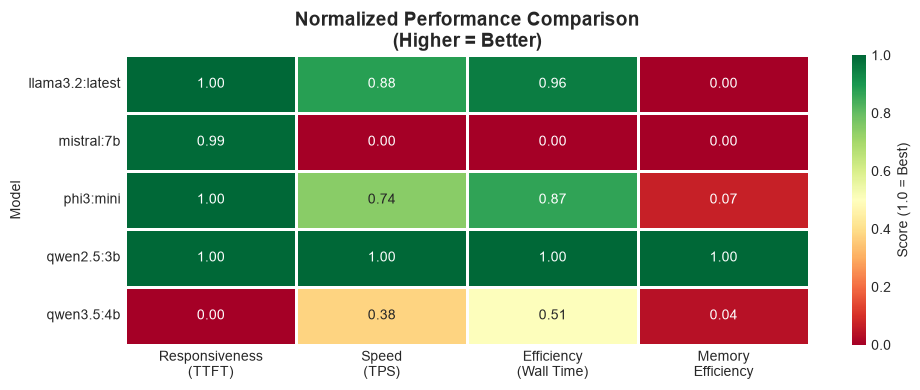

In [8]:
# Create normalized comparison matrix
perf_metrics = df.groupby('model').agg({
    'ttft_s': 'median',
    'tps_eval': 'median', 
    'wall_s': 'median',
    'mem_peak_mib': 'max'
}).reset_index()

# Normalize: for TPS higher is better, for others lower is better
perf_norm = perf_metrics.copy()
perf_norm['ttft_s'] = 1 - (perf_metrics['ttft_s'] - perf_metrics['ttft_s'].min()) / (perf_metrics['ttft_s'].max() - perf_metrics['ttft_s'].min() + 0.001)
perf_norm['tps_eval'] = (perf_metrics['tps_eval'] - perf_metrics['tps_eval'].min()) / (perf_metrics['tps_eval'].max() - perf_metrics['tps_eval'].min() + 0.001)
perf_norm['wall_s'] = 1 - (perf_metrics['wall_s'] - perf_metrics['wall_s'].min()) / (perf_metrics['wall_s'].max() - perf_metrics['wall_s'].min() + 0.001)
perf_norm['mem_peak_mib'] = 1 - (perf_metrics['mem_peak_mib'] - perf_metrics['mem_peak_mib'].min()) / (perf_metrics['mem_peak_mib'].max() - perf_metrics['mem_peak_mib'].min() + 0.001)

# Rename columns for display
perf_norm.columns = ['Model', 'Responsiveness\n(TTFT)', 'Speed\n(TPS)', 'Efficiency\n(Wall Time)', 'Memory\nEfficiency']

fig, ax = plt.subplots(figsize=(10, 4))

# Create heatmap
heatmap_data = perf_norm.set_index('Model')
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0.5, 
            fmt='.2f', linewidths=2, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Score (1.0 = Best)'})

ax.set_title('Normalized Performance Comparison\n(Higher = Better)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### 🧒 ELI5: The Report Card! 📝

This is like a report card for each robot!

- 🟢 **Green** = Great job! (score close to 1.0)
- 🟡 **Yellow** = Okay (score around 0.5)
- 🔴 **Red** = Needs improvement (score close to 0)

The robot with the most green boxes is the class star! ⭐

---

## 6. Time Series: Run-to-Run Consistency

**Technical insight**: Are results stable across runs? Variance matters for production.

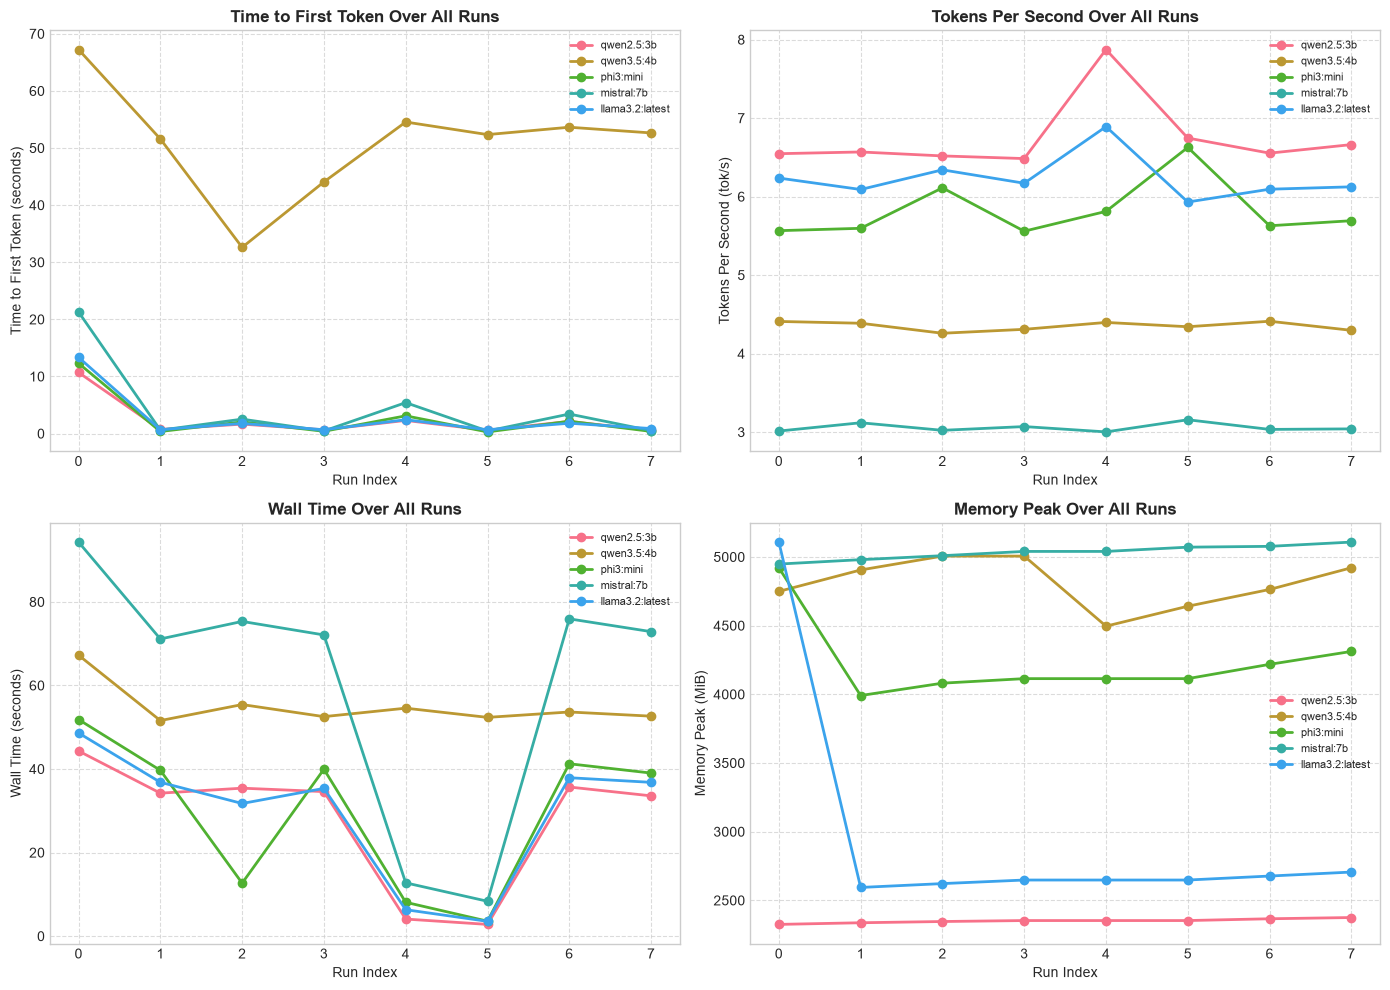

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['ttft_s', 'tps_eval', 'wall_s', 'mem_peak_mib']
titles = ['Time to First Token', 'Tokens Per Second', 'Wall Time', 'Memory Peak']
units = ['seconds', 'tok/s', 'seconds', 'MiB']

for idx, (metric, title, unit) in enumerate(zip(metrics, titles, units)):
    ax = axes[idx // 2, idx % 2]
    
    for model in df['model'].unique():
        model_data = df[df['model'] == model].sort_values(['prompt_i', 'run_i'])
        model_data = model_data.reset_index(drop=True)
        ax.plot(model_data.index, model_data[metric], marker='o', label=model, linewidth=2, markersize=6)
    
    ax.set_title(f'{title} Over All Runs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Run Index', fontsize=10)
    ax.set_ylabel(f'{title} ({unit})', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 🧒 ELI5: Consistency Check! 📏

These lines show if the robot behaves the same way every time you ask it something.

- **Flat lines** = The robot is very predictable! 👍
- **Wobbly lines** = The robot is a bit random! 🎲

We like robots that always behave the same way - no surprises!

---

# 🏆 Final Rankings

In [10]:
# Calculate composite scores
rankings = df.groupby('model').agg({
    'ttft_s': 'median',
    'tps_eval': 'median',
    'wall_s': 'median',
    'mem_peak_mib': 'max'
}).reset_index()

# Rank each metric (1 = best)
rankings['ttft_rank'] = rankings['ttft_s'].rank()
rankings['tps_rank'] = rankings['tps_eval'].rank(ascending=False)  # Higher is better
rankings['wall_rank'] = rankings['wall_s'].rank()
rankings['mem_rank'] = rankings['mem_peak_mib'].rank()

# Composite score (lower is better)
rankings['composite_rank'] = rankings[['ttft_rank', 'tps_rank', 'wall_rank', 'mem_rank']].mean(axis=1)
rankings = rankings.sort_values('composite_rank')

print("🏆 FINAL RANKINGS 🏆\n")
print("="*60)
for i, row in enumerate(rankings.itertuples(), 1):
    medal = {1: '🥇', 2: '🥈', 3: '🥉'}.get(i, f'{i}.')
    print(f"{medal} {row.model}")
    print(f"   TTFT: {row.ttft_s:.3f}s | TPS: {row.tps_eval:.1f} | Wall: {row.wall_s:.2f}s | Mem: {row.mem_peak_mib:.0f} MiB")
    print(f"   Composite Score: {row.composite_rank:.2f}")
    print()

🏆 FINAL RANKINGS 🏆

🥇 qwen2.5:3b
   TTFT: 1.186s | TPS: 6.6 | Wall: 34.40s | Mem: 2375 MiB
   Composite Score: 1.00

🥈 phi3:mini
   TTFT: 1.219s | TPS: 5.7 | Wall: 39.35s | Mem: 4921 MiB
   Composite Score: 2.50

🥉 llama3.2:latest
   TTFT: 1.326s | TPS: 6.1 | Wall: 36.08s | Mem: 5108 MiB
   Composite Score: 2.88

4. qwen3.5:4b
   TTFT: 52.494s | TPS: 4.4 | Wall: 53.14s | Mem: 5006 MiB
   Composite Score: 4.00

5. mistral:7b
   TTFT: 1.558s | TPS: 3.0 | Wall: 72.47s | Mem: 5108 MiB
   Composite Score: 4.62



### 🧒 ELI5: And the Winner Is...! 🎉

We looked at everything:
- How fast the robot starts talking
- How fast it talks
- When it finishes
- How much lunch it needs

**🥇 Gold medal** goes to the robot that does the best overall!

---

## 🎯 Recommendations

Based on these results:

| Use Case | Recommended Model | Why? |
|----------|------------------|------|
| **Chatbots** | Lowest TTFT | Users hate waiting for first response |
| **Batch Processing** | Highest TPS | Throughput matters more than latency |
| **Resource-Constrained** | Lowest Memory | Fits on smaller hardware |
| **General Purpose** | Best Composite | Balanced across all metrics |

---

## 📊 Export Summary

In [11]:
# Export summary to CSV
export_df = rankings[['model', 'ttft_s', 'tps_eval', 'wall_s', 'mem_peak_mib', 'composite_rank']].copy()
export_df.columns = ['Model', 'TTFT (s)', 'TPS', 'Wall Time (s)', 'Peak Memory (MiB)', 'Composite Score']
# export_df.to_csv('benchmark_summary.csv', index=False)

print("📤 Summary ready for export:\n")
export_df.round(3)

📤 Summary ready for export:



,Model,TTFT (s),TPS,Wall Time (s),Peak Memory (MiB),Composite Score
3,qwen2.5:3b,1.186,6.561,34.398,2375.0,1.000
2,phi3:mini,1.219,5.661,39.349,4921.0,2.500
0,llama3.2:latest,1.326,6.147,36.076,5108.0,2.875
4,qwen3.5:4b,52.494,4.364,53.139,5006.0,4.000
1,mistral:7b,1.558,3.037,72.473,5108.0,4.625
